# Decission Tree

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
import pickle

## Definir get_metrics

>Definimos la funcion get_classifier_metrics para analizar los datos que tenemos con los modelos

In [122]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='micro'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

## Recolección de Datos

>Los DataFrames completos

In [123]:
with open('/workspaces/adamcn10-intro-ml/data/processed/decision-tree-df-nonull.pkl', 'rb') as file:
    df_nonull = pickle.load(file)

with open('/workspaces/adamcn10-intro-ml/data/processed/decision-tree-df-most-frequent.pkl', 'rb') as file:
    df_most_freq = pickle.load(file)

with open('/workspaces/adamcn10-intro-ml/data/processed/decision-tree-df-knn.pkl', 'rb') as file:
    df_knn = pickle.load(file)

>Datos eliminando valores nulos

In [124]:
X_test_nonull = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-test-nonull.csv', 
                            index_col=0)
X_train_nonull = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-train-nonull.csv', 
                            index_col=0)
y_test_nonull = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-test-nonull.csv', 
                            index_col=0)
y_train_nonull = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-train-nonull.csv', 
                            index_col=0)

>Datos sustituyendo 0 por la moda

In [125]:
X_test_most_freq = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-test-most-frequent.csv',
                            index_col=0)
X_train_most_freq = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-train-most-frequent.csv', 
                            index_col=0)
y_test_most_freq = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-test-most-frequent.csv', 
                            index_col=0)
y_train_most_freq = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-train-most-frequent.csv', 
                            index_col=0)

>Datos aplicando KNN Imputer

In [126]:
X_test_knn = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-test-knn.csv', 
                            index_col=0)
X_train_knn = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-X-train-knn.csv', 
                            index_col=0)
y_test_knn = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-test-knn.csv', 
                            index_col=0)
y_train_knn = pd.read_csv('/workspaces/adamcn10-intro-ml/data/edas/decission-tree-y-train-knn.csv', 
                            index_col=0)

## Modelados

### Modelo eliminando 0s

In [127]:
model_nonull = DecisionTreeClassifier(random_state = 25)
model_nonull.fit(X_train_nonull, y_train_nonull)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [128]:
y_pred_train_nonull = model_nonull.predict(X_train_nonull)
y_pred_test_nonull = model_nonull.predict(X_test_nonull)
pd.DataFrame(y_pred_test_nonull)

,0
0,0
1,1
2,1
3,0
4,1
...,...
74,1
75,0
76,1
77,0


In [129]:
y_test_nonull

,Outcome
243,1
364,0
469,0
692,0
478,0
...,...
539,1
122,0
689,1
285,0


In [130]:
report_nonull = classification_report(y_test_nonull, y_pred_test_nonull)
print(report_nonull)

              precision    recall  f1-score   support

           0       0.74      0.77      0.75        52
           1       0.52      0.48      0.50        27

    accuracy                           0.67        79
   macro avg       0.63      0.63      0.63        79
weighted avg       0.67      0.67      0.67        79



In [131]:
get_classifier_metrics(y_pred_test_nonull, y_test_nonull, y_pred_train_nonull, y_train_nonull)

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.670886,0.670886,0.670886,0.670886


### Modelo sustituyendo por moda

In [132]:
model_most_freq = DecisionTreeClassifier(random_state = 25)
model_most_freq.fit(X_train_most_freq, y_train_most_freq)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [133]:
y_pred_train_most_freq = model_most_freq.predict(X_train_most_freq)
y_pred_test_most_freq = model_most_freq.predict(X_test_most_freq)
pd.DataFrame(y_pred_test_most_freq)

,0
0,0
1,0
2,0
3,1
4,0
...,...
149,0
150,1
151,1
152,0


In [134]:
y_test_most_freq

,Outcome
459,0
39,1
344,0
84,1
700,0
...,...
410,0
114,1
246,0
506,1


In [135]:
report_most_freq = classification_report(y_test_most_freq, y_pred_test_most_freq)
print(report_most_freq)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       103
           1       0.63      0.63      0.63        51

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [136]:
get_classifier_metrics(y_pred_test_most_freq, y_test_most_freq, y_pred_train_most_freq, y_train_most_freq)

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.753247,0.753247,0.753247,0.753247


### Modelo aplicando KNN 

In [137]:
model_knn = DecisionTreeClassifier(random_state = 25)
model_knn.fit(X_train_knn, y_train_knn)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [138]:
y_pred_train_knn = model_knn.predict(X_train_knn)
y_pred_test_knn = model_knn.predict(X_test_knn)
pd.DataFrame(y_pred_test_knn)

,0
0,0
1,0
2,0
3,1
4,0
...,...
149,0
150,1
151,1
152,0


In [139]:
y_test_knn

,Outcome
459,0
39,1
344,0
84,1
700,0
...,...
410,0
114,1
246,0
506,1


In [140]:
report_knn = classification_report(y_test_knn, y_pred_test_knn)
print(report_knn)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       103
           1       0.63      0.63      0.63        51

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [141]:
get_classifier_metrics(y_pred_test_knn, y_test_knn, y_pred_train_knn, y_train_knn)

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.753247,0.753247,0.753247,0.753247


## Graficos

### Modelo eliminando 0s

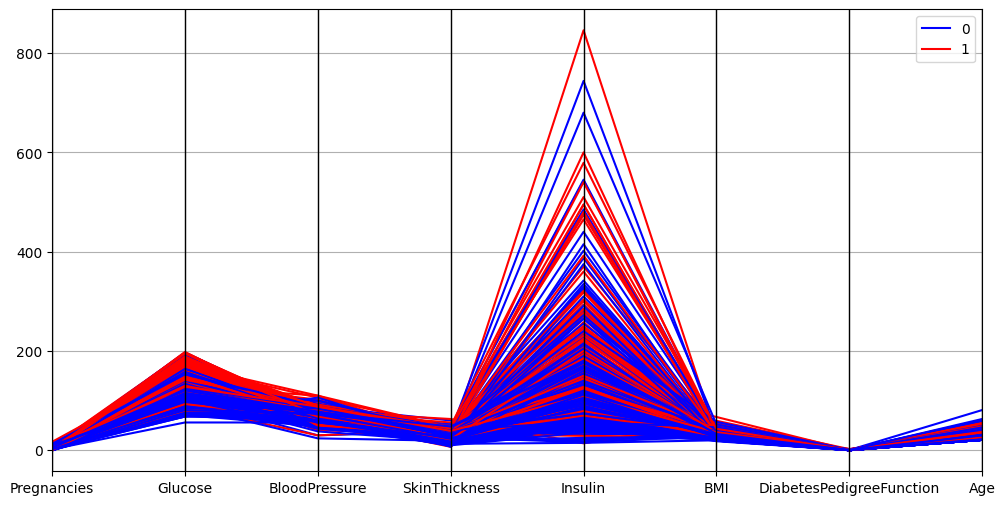

In [142]:
plt.figure(figsize=(12, 6))

pd.plotting.parallel_coordinates(df_nonull, "Outcome", color=('b', 'r'))

plt.show()

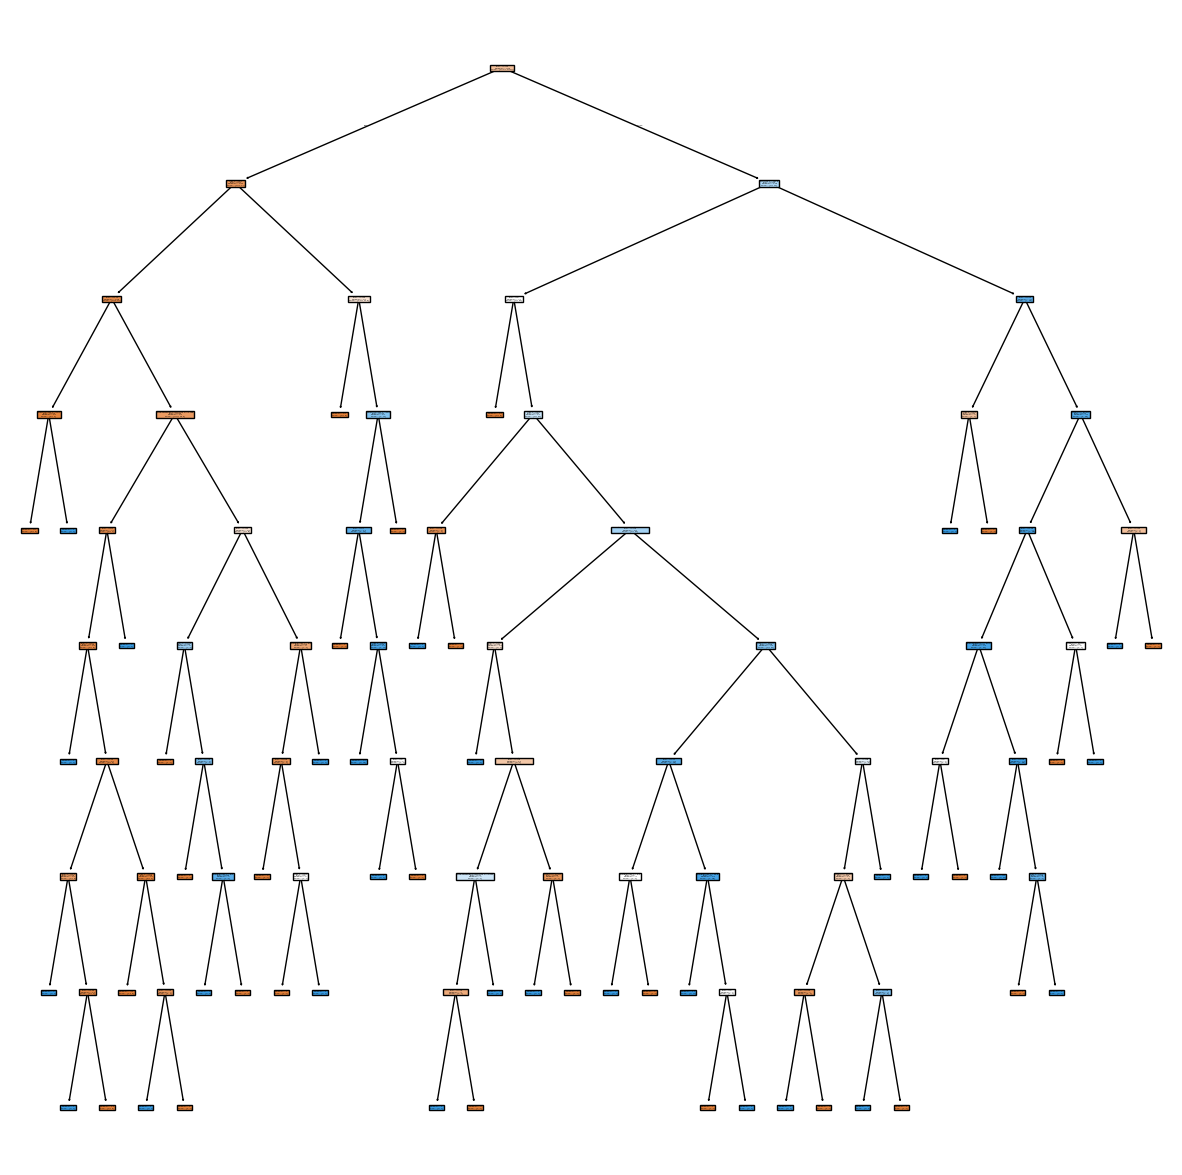

In [143]:
fig = plt.figure(figsize=(15,15))

plot_tree(model_nonull, feature_names = list(X_train_nonull.columns), filled=True)

plt.show()

### Modelo sustituyendo por moda

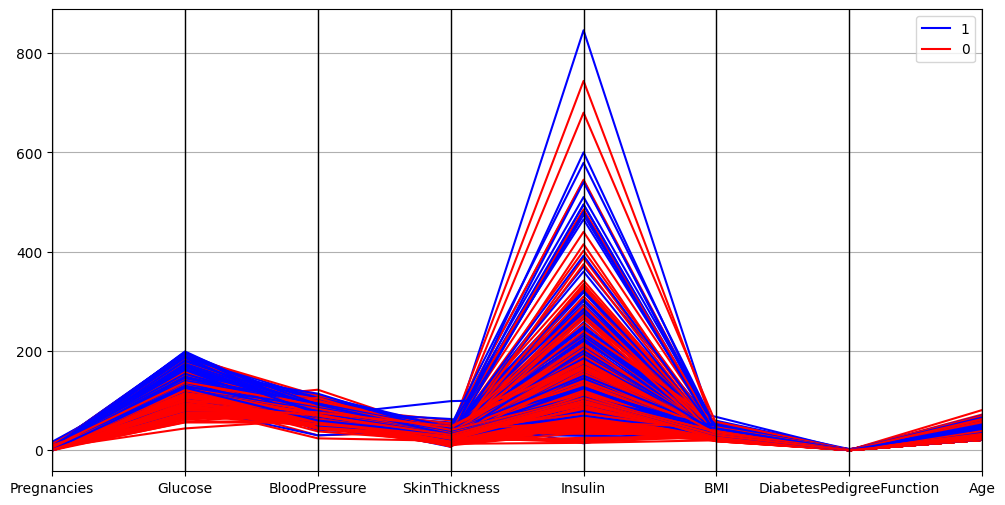

In [144]:
plt.figure(figsize=(12, 6))

pd.plotting.parallel_coordinates(df_most_freq, "Outcome", color=('b', 'r'))

plt.show()

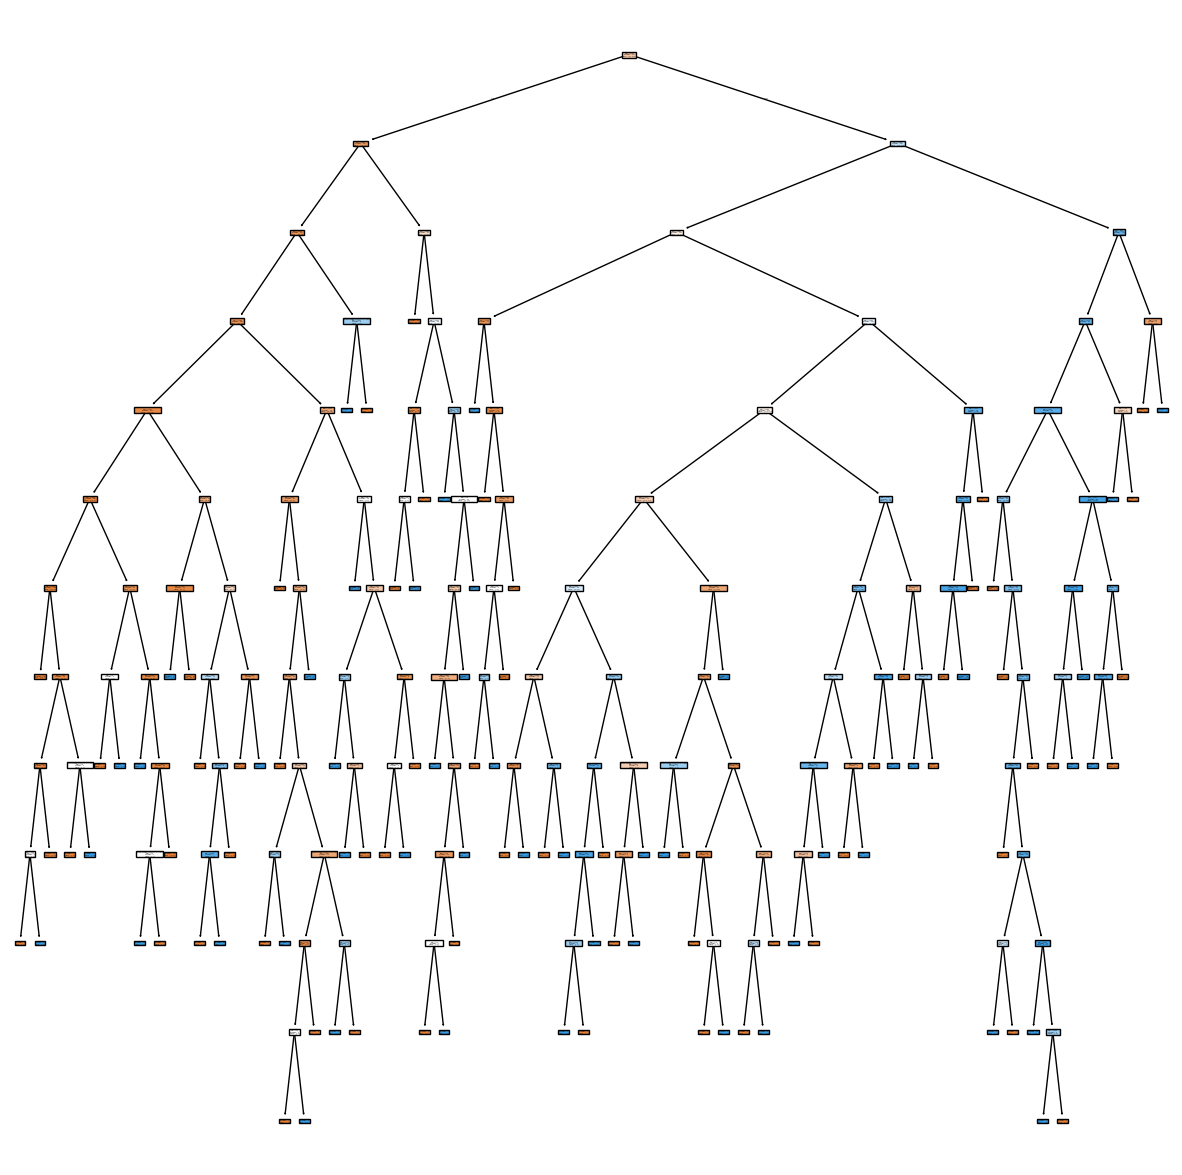

In [145]:
fig = plt.figure(figsize=(15,15))

plot_tree(model_most_freq, feature_names = list(X_train_most_freq.columns), filled=True)

plt.show()

### Modelo aplicando KNN 

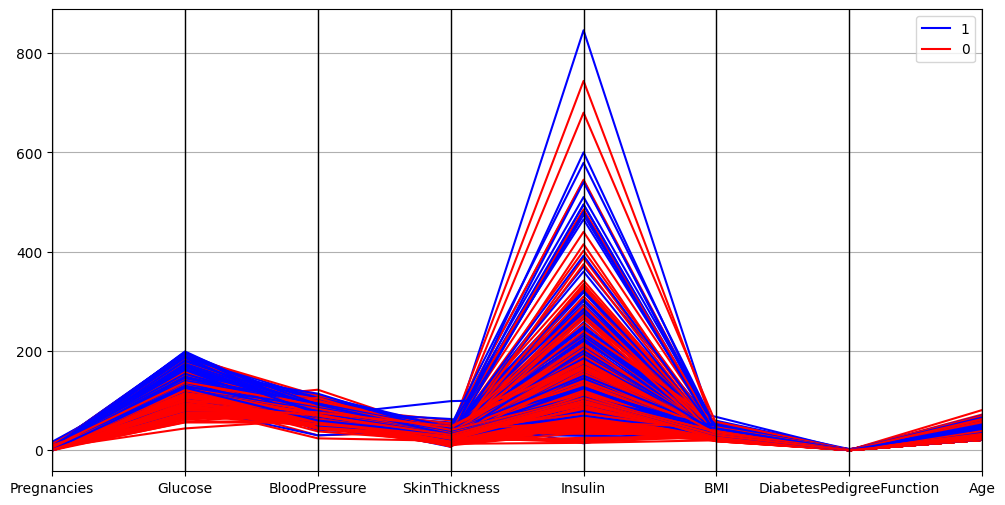

In [146]:
plt.figure(figsize=(12, 6))

pd.plotting.parallel_coordinates(df_knn, "Outcome", color=('b', 'r'))

plt.show()

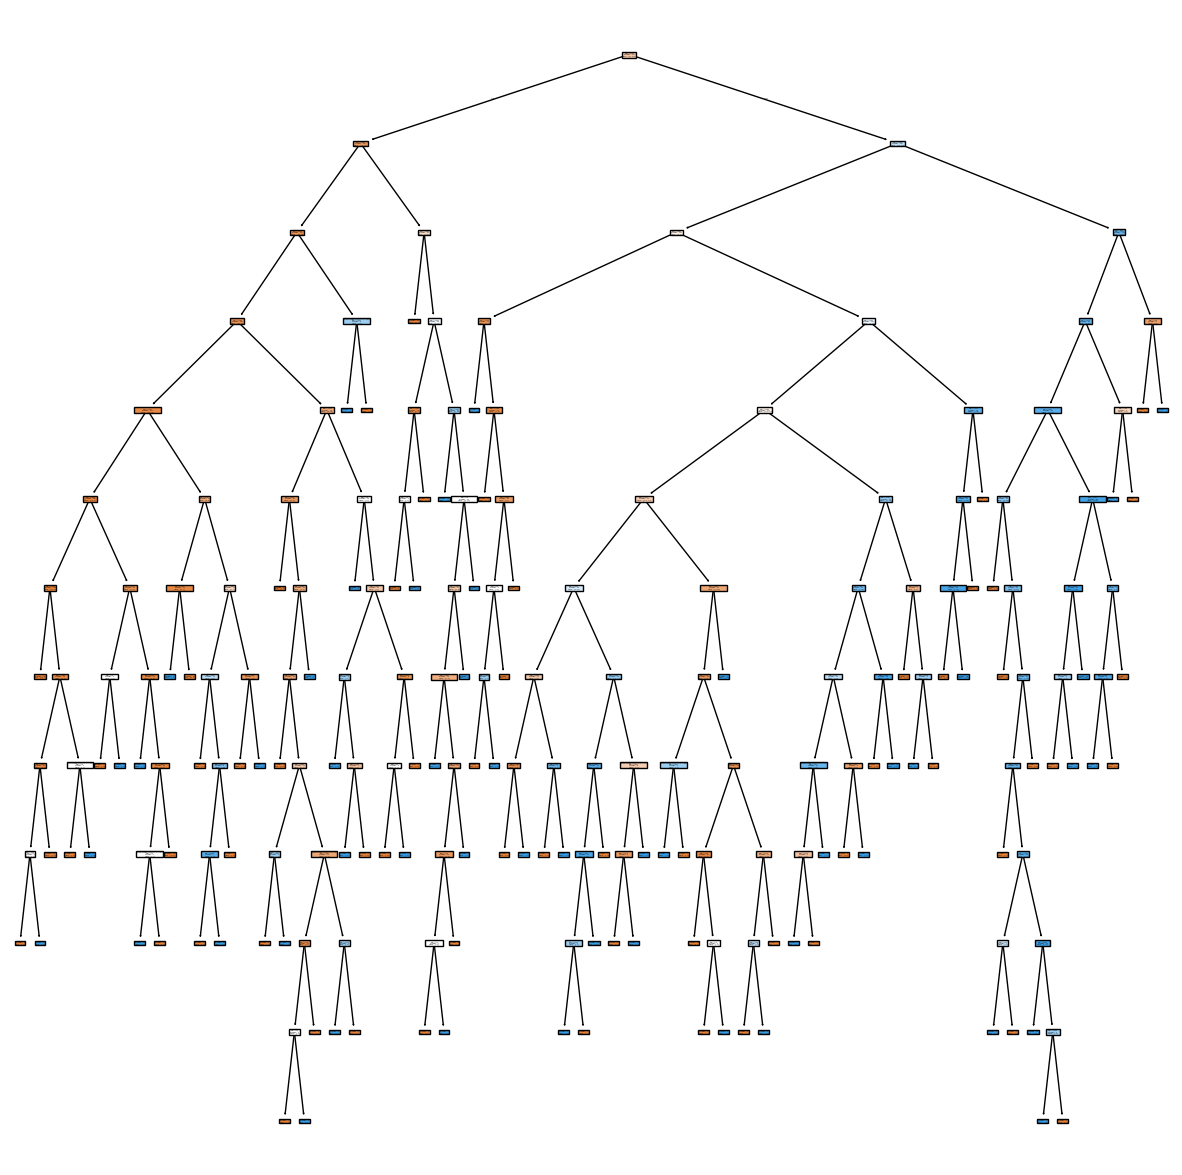

In [147]:
fig = plt.figure(figsize=(15,15))

plot_tree(model_knn, feature_names = list(X_train_knn.columns), filled=True)

plt.show()

## Optimización de modelos

>Vamos a utilizar GridCV con el scoring recall ya que es el que nos interesa para la temática médica que tenemos en este proyecto para optimizar los tres modelos

In [148]:
hyperparams = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

### Modelo eliminando 0s

In [149]:
grid_nonull = GridSearchCV(model_nonull, hyperparams, scoring = "recall", cv = 10)
grid_nonull

,estimator,DecisionTreeC...ndom_state=25)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [150]:
grid_nonull.fit(X_train_nonull, y_train_nonull)

grid_nonull.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2}

In [151]:
grid_nonull.best_estimator_

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [152]:
best_model_nonull = grid_nonull.best_estimator_
y_pred_best_nonull = best_model_nonull.predict(X_test_nonull)
grid_report_nonull = classification_report(y_test_nonull, y_pred_best_nonull)

print(report_nonull, grid_report_nonull)


              precision    recall  f1-score   support

           0       0.74      0.77      0.75        52
           1       0.52      0.48      0.50        27

    accuracy                           0.67        79
   macro avg       0.63      0.63      0.63        79
weighted avg       0.67      0.67      0.67        79
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        52
           1       0.65      0.63      0.64        27

    accuracy                           0.76        79
   macro avg       0.73      0.73      0.73        79
weighted avg       0.76      0.76      0.76        79



### Modelo sustituyendo por moda

In [153]:
grid_most_freq = GridSearchCV(model_most_freq, hyperparams, scoring = "recall", cv = 10)
grid_most_freq

,estimator,DecisionTreeC...ndom_state=25)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [154]:
grid_most_freq.fit(X_train_most_freq, y_train_most_freq)

grid_most_freq.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [155]:
grid_most_freq.best_estimator_

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [156]:
best_model_most_freq = grid_most_freq.best_estimator_
y_pred_best_most_freq = best_model_most_freq.predict(X_test_most_freq)
grid_report_most_freq = classification_report(y_test_most_freq, y_pred_best_most_freq)

print(report_most_freq, grid_report_most_freq)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       103
           1       0.63      0.63      0.63        51

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154
               precision    recall  f1-score   support

           0       0.88      0.68      0.77       103
           1       0.55      0.80      0.66        51

    accuracy                           0.72       154
   macro avg       0.71      0.74      0.71       154
weighted avg       0.77      0.72      0.73       154



### Modelo aplicando KNN 

In [157]:
grid_knn = GridSearchCV(model_knn, hyperparams, scoring = "recall", cv = 10)
grid_knn

,estimator,DecisionTreeC...ndom_state=25)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [158]:
grid_knn.fit(X_train_knn, y_train_knn)

grid_knn.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [159]:
grid_knn.best_estimator_

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [160]:
best_model_knn = grid_knn.best_estimator_
y_pred_best_knn = best_model_knn.predict(X_test_knn)
grid_report_knn = classification_report(y_test_knn, y_pred_best_knn)

print(report_knn, grid_report_knn)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       103
           1       0.63      0.63      0.63        51

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154
               precision    recall  f1-score   support

           0       0.88      0.68      0.77       103
           1       0.55      0.80      0.66        51

    accuracy                           0.72       154
   macro avg       0.71      0.74      0.71       154
weighted avg       0.77      0.72      0.73       154



### Valoración de modelos

>Dado que estamos ante un tema médico, la métrica que más nos interesa es la métrica recall, que analiza los verdaderos positivos entre verdaderos positivos y falsos negativos, vamos a compararlos todos, de los 3 modelos básicos y los 3 optimizados para decidir con cual nos quedamos al final

In [161]:
results = {}

results['nonull_recall'] = recall_score(y_test_nonull, y_pred_test_nonull)
results['most_freq_recall'] = recall_score(y_test_most_freq, y_pred_test_most_freq)
results['knn_recall'] = recall_score(y_test_knn, y_pred_test_knn)
results['nonull_grid_recall'] = recall_score(y_test_nonull, y_pred_best_nonull)
results['most_freq_grid_recall'] = recall_score(y_test_most_freq, y_pred_best_most_freq)
results['knn_grid_recall'] = recall_score(y_test_knn, y_pred_best_knn)

results

{'nonull_recall': 0.48148148148148145,
 'most_freq_recall': 0.6274509803921569,
 'knn_recall': 0.6274509803921569,
 'nonull_grid_recall': 0.6296296296296297,
 'most_freq_grid_recall': 0.803921568627451,
 'knn_grid_recall': 0.803921568627451}

> ### Grafica comparativa de Sensibilidad de los modelos
>|Modelo     |Eliminando nulos   |Sustituyendo por moda|k-nearest neighbors|
>|-----------|-------------------|---------------------|-------------------|
>|Modelo base|0.48148148148148145|0.6274509803921569   |0.6274509803921569 |
>|GridCV     |0.6296296296296297 |0.803921568627451    |0.803921568627451  |

>### Observaciones - Conclusiones
> Los modelos sustituyendo por la moda y con KNN Imputer son sensiblemente mejores que el eliminando los nulos, además de que la optimización del modelo usando GridCV hace que también mejoren sustancialmente. Vemos también que tanto por la moda como con KNN dan el mismo resultado y estos optimizados son los mejores modelos que tenemos ahora mismo.

## Guardado de modelos

>Guardaré igualmente los 6 modelos en models

In [162]:
with open('/workspaces/adamcn10-intro-ml/models/decission-tree-nonull.pkl', 'wb') as file:
    pickle.dump(model_nonull, file)     

with open('/workspaces/adamcn10-intro-ml/models/decission-tree-most-freq.pkl', 'wb') as file:
    pickle.dump(model_most_freq, file)     

with open('/workspaces/adamcn10-intro-ml/models/decission-tree-knn.pkl', 'wb') as file:
    pickle.dump(model_knn, file)     

with open('/workspaces/adamcn10-intro-ml/models/decission-tree-nonull-grid.pkl', 'wb') as file:
    pickle.dump(best_model_nonull, file)     

with open('/workspaces/adamcn10-intro-ml/models/decission-tree-most-freq-grid.pkl', 'wb') as file:
    pickle.dump(best_model_most_freq, file)     

with open('/workspaces/adamcn10-intro-ml/models/decission-tree-knn-grid.pkl', 'wb') as file:
    pickle.dump(best_model_knn, file)     